# TesTEA - Analisis Exploratorio de Datos (EDA)

Proyecto de cribado temprano de TEA (Trastorno del Espectro Autista) basado en Machine Learning.

El objetivo de este notebook es explorar y entender los datasets que vamos a utilizar
para entrenar nuestros modelos de clasificacion. Necesitamos conocer bien los datos
antes de tomar cualquier decision sobre preprocesamiento o modelado.

Trabajamos con tres datasets procedentes de UCI Machine Learning Repository y Kaggle,
todos basados en el cuestionario estandarizado AQ-10 (Autism Quotient de 10 items):

- **autism_screening.csv**: datos de adultos (UCI)
- **Autism_Screening_Data_Combined.csv**: coleccion agrupada de adultos, adolescentes y ninos (Kaggle)
- **Toddler_Autism_dataset_July_2018.csv**: datos de ninos pequenos / toddlers (Kaggle)


## 0. Imports y configuracion

In [1]:
# Importamos las librerias necesarias para el analisis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracion visual para que los graficos se vean bien
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12


ModuleNotFoundError: No module named 'pandas'

## 1. Carga de datos

Cargamos los tres datasets en DataFrames separados para poder explorar cada uno
de forma independiente. Las rutas apuntan a la carpeta data/raw/ del proyecto.

Si trabajamos en Google Colab, hay que montar Google Drive primero y ajustar
las rutas segun donde tengamos clonado el repositorio.


In [ ]:
# Cargamos cada dataset en un DataFrame separado
# Ajustar estas rutas segun el entorno de trabajo (local o Colab)
autism_adults = pd.read_csv("../data/raw/autism_screening.csv")
autism_combined = pd.read_csv("../data/raw/Autism_Screening_Data_Combined.csv")
autism_toddlers = pd.read_csv("../data/raw/Toddler_Autism_dataset_July_2018.csv")

print("Datasets cargados correctamente")
print(f"  - autism_adults:    {autism_adults.shape[0]} registros, {autism_adults.shape[1]} columnas")
print(f"  - autism_combined:  {autism_combined.shape[0]} registros, {autism_combined.shape[1]} columnas")
print(f"  - autism_toddlers:  {autism_toddlers.shape[0]} registros, {autism_toddlers.shape[1]} columnas")
print(f"  - Total de registros entre los tres: {autism_adults.shape[0] + autism_combined.shape[0] + autism_toddlers.shape[0]}")


Datasets cargados correctamente
  - autism_adults:    704 registros, 21 columnas
  - autism_combined:  6075 registros, 15 columnas
  - autism_toddlers:  1054 registros, 19 columnas
  - Total de registros entre los tres: 7833


## 2. Estructura de cada dataset

Antes de hacer nada, necesitamos entender que columnas tiene cada dataset,
que tipos de datos contiene cada una, y si comparten una estructura comun
(ya que los tres estan basados en el cuestionario AQ-10).


### 2.1 Dataset de adultos (autism_adults)

In [ ]:
# Vemos las primeras filas para hacernos una idea general del contenido
print("Primeras 5 filas del dataset de adultos:")
print(autism_adults.head())
print()

# Tipos de datos de cada columna
print("Tipos de datos:")
print(autism_adults.dtypes)
print()

# Nombres de todas las columnas para tener la referencia completa
print("Columnas:", list(autism_adults.columns))


Primeras 5 filas del dataset de adultos:
   A1_Score  A2_Score  A3_Score  A4_Score  A5_Score  A6_Score  A7_Score  \
0         1         1         1         1         0         0         1   
1         1         1         0         1         0         0         0   
2         1         1         0         1         1         0         1   
3         1         1         0         1         0         0         1   
4         1         0         0         0         0         0         0   

   A8_Score  A9_Score  A10_Score  ...  gender       ethnicity jundice austim  \
0         1         0          0  ...       f  White-European      no     no   
1         1         0          1  ...       m          Latino      no    yes   
2         1         1          1  ...       m          Latino     yes    yes   
3         1         0          1  ...       f  White-European      no    yes   
4         1         0          0  ...       f               ?      no     no   

   contry_of_res used_app_b

### 2.2 Dataset combinado (autism_combined)

In [ ]:
# Vemos las primeras filas del dataset combinado
print("Primeras 5 filas del dataset combinado:")
print(autism_combined.head())
print()

# Tipos de datos
print("Tipos de datos:")
print(autism_combined.dtypes)
print()

# Columnas
print("Columnas:", list(autism_combined.columns))


Primeras 5 filas del dataset combinado:
   A1  A2  A3  A4  A5  A6  A7  A8  A9  A10  Age Sex Jauundice Family_ASD Class
0   1   1   0   1   0   0   1   1   0    0   15   m        no         no    NO
1   0   1   1   1   0   1   1   0   1    0   15   m        no         no    NO
2   1   1   1   0   1   1   1   1   1    1   15   f        no        yes   YES
3   1   1   1   1   1   1   1   1   0    0   16   f        no         no   YES
4   1   1   1   1   1   1   1   1   1    1   15   f        no         no   YES

Tipos de datos:
A1            int64
A2            int64
A3            int64
A4            int64
A5            int64
A6            int64
A7            int64
A8            int64
A9            int64
A10           int64
Age           int64
Sex             str
Jauundice       str
Family_ASD      str
Class           str
dtype: object

Columnas: ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age', 'Sex', 'Jauundice', 'Family_ASD', 'Class']


### 2.3 Dataset de toddlers (autism_toddlers)

In [ ]:
# Vemos las primeras filas del dataset de toddlers
print("Primeras 5 filas del dataset de toddlers:")
print(autism_toddlers.head())
print()

# Tipos de datos
print("Tipos de datos:")
print(autism_toddlers.dtypes)
print()

# Columnas
print("Columnas:", list(autism_toddlers.columns))


Primeras 5 filas del dataset de toddlers:
   Case_No  A1  A2  A3  A4  A5  A6  A7  A8  A9  A10  Age_Mons  Qchat-10-Score  \
0        1   0   0   0   0   0   0   1   1   0    1        28               3   
1        2   1   1   0   0   0   1   1   0   0    0        36               4   
2        3   1   0   0   0   0   0   1   1   0    1        36               4   
3        4   1   1   1   1   1   1   1   1   1    1        24              10   
4        5   1   1   0   1   1   1   1   1   1    1        20               9   

  Sex       Ethnicity Jaundice Family_mem_with_ASD Who completed the test  \
0   f  middle eastern      yes                  no          family member   
1   m  White European      yes                  no          family member   
2   m  middle eastern      yes                  no          family member   
3   m        Hispanic       no                  no          family member   
4   f  White European       no                 yes          family member   

  Class/

### 2.4 Comparacion de estructuras entre datasets

Los tres datasets comparten la base del cuestionario AQ-10 (columnas A1 a A10),
pero tienen diferencias importantes en las columnas adicionales:

| Columna | autism_adults | autism_combined | autism_toddlers |
|---|---|---|---|
| Respuestas AQ-10 | A1_Score a A10_Score | A1 a A10 | A1 a A10 |
| Edad | age (anos) | Age (anos) | Age_Mons (meses) |
| Sexo | gender | Sex | Sex |
| Etnia | ethnicity | -- | Ethnicity |
| Ictericia neonatal | jundice | Jauundice | Jaundice |
| Antecedentes familiares | austim | Family_ASD | Family_mem_with_ASD |
| Pais | contry_of_res | -- | -- |
| Quien completa el test | relation | -- | Who completed the test |
| Puntuacion total | result | -- | Qchat-10-Score |
| Uso previo de app | used_app_before | -- | -- |
| Descriptor de edad | age_desc | -- | -- |
| Target | Class/ASD | Class | Class/ASD Traits |

Esto es importante porque a la hora de unificar los datasets para el modelado
tendremos que homogeneizar los nombres y tratar las columnas que no existen
en todos los datasets.


## 3. Valores faltantes

Comprobamos si hay valores nulos en cada dataset. Los valores faltantes pueden
afectar al rendimiento de los modelos y hay que decidir como tratarlos
(eliminar filas, imputar valores, etc.).


In [ ]:
# Revisamos los valores faltantes en cada dataset
print("=" * 60)
print("VALORES FALTANTES - autism_adults")
print("=" * 60)
nulos_adults = autism_adults.isnull().sum()
# Solo mostramos las columnas que tienen algun nulo para no llenar la pantalla
nulos_con_valores = nulos_adults[nulos_adults > 0]
if len(nulos_con_valores) > 0:
    print(nulos_con_valores)
    print(f"\nTotal de filas con al menos un nulo: {autism_adults.isnull().any(axis=1).sum()}")
else:
    print("No hay valores faltantes")

print()
print("=" * 60)
print("VALORES FALTANTES - autism_combined")
print("=" * 60)
nulos_combined = autism_combined.isnull().sum()
nulos_con_valores = nulos_combined[nulos_combined > 0]
if len(nulos_con_valores) > 0:
    print(nulos_con_valores)
else:
    print("No hay valores faltantes")

print()
print("=" * 60)
print("VALORES FALTANTES - autism_toddlers")
print("=" * 60)
nulos_toddlers = autism_toddlers.isnull().sum()
nulos_con_valores = nulos_toddlers[nulos_toddlers > 0]
if len(nulos_con_valores) > 0:
    print(nulos_con_valores)
else:
    print("No hay valores faltantes")


VALORES FALTANTES - autism_adults
age    2
dtype: int64

Total de filas con al menos un nulo: 2

VALORES FALTANTES - autism_combined
No hay valores faltantes

VALORES FALTANTES - autism_toddlers
No hay valores faltantes


### Observaciones sobre valores faltantes

- **autism_adults**: tiene 2 valores faltantes en la columna 'age'. Son solo 2 de 704
  registros (0.28%), asi que podemos imputarlos con la mediana o simplemente eliminar
  esas filas sin perder informacion relevante.
- **autism_combined** y **autism_toddlers**: no tienen valores faltantes.

Tambien hay que tener en cuenta que en autism_adults algunas columnas categoricas
tienen el valor '?' como dato desconocido, que pandas no detecta como nulo pero
que en la practica es un valor faltante. Vamos a comprobarlo.


In [ ]:
# Comprobamos si hay valores '?' en las columnas categoricas de autism_adults
# porque el dataset de UCI a veces usa '?' en lugar de NaN
print("Valores '?' en columnas categoricas de autism_adults:")
cols_categoricas = autism_adults.select_dtypes(include=["object"]).columns
for col in cols_categoricas:
    count_interrogacion = (autism_adults[col] == "?").sum()
    if count_interrogacion > 0:
        print(f"  {col}: {count_interrogacion} valores '?'")


Valores '?' en columnas categoricas de autism_adults:
  ethnicity: 95 valores '?'
  relation: 95 valores '?'


/tmp/ipykernel_533/2562270487.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_categoricas = autism_adults.select_dtypes(include=["object"]).columns


## 4. Distribucion de la variable objetivo (target)

La variable objetivo es la etiqueta de cribado: si el resultado del test indica
rasgos compatibles con TEA (YES/Yes) o no (NO/No).

Esto es fundamental porque si las clases estan muy desbalanceadas, tendremos
que tener cuidado con las metricas que usemos para evaluar los modelos.
En un contexto de cribado medico, un falso negativo (no detectar a alguien que
si tiene rasgos de TEA) es mucho mas grave que un falso positivo (derivar a
alguien que al final no lo necesita). Por eso priorizaremos el recall.


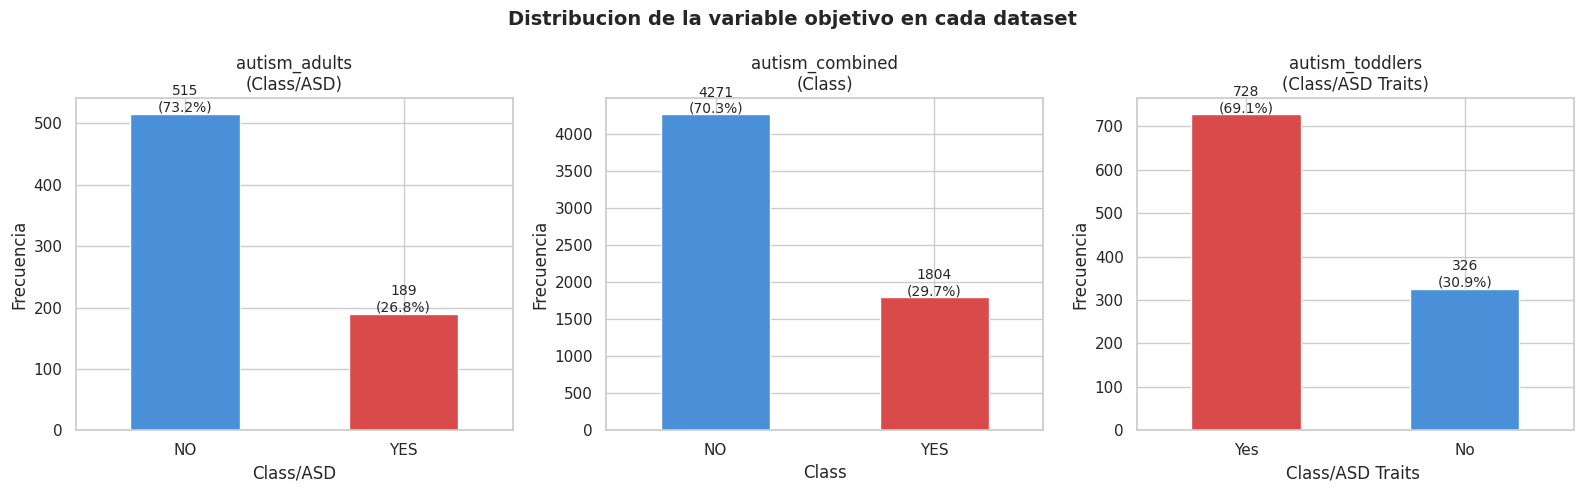

Resumen de balance de clases:
  autism_adults:   NO=515 (73.2%) | YES=189 (26.8%)
  autism_combined: NO=4271 (70.3%) | YES=1804 (29.7%)
  autism_toddlers: No=326 (30.9%) | Yes=728 (69.1%)


In [ ]:
# Distribucion de la variable objetivo en cada dataset
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# autism_adults
counts_adults = autism_adults["Class/ASD"].value_counts()
counts_adults.plot(kind="bar", ax=axes[0], color=["#4a90d9", "#d94a4a"])
axes[0].set_title("autism_adults\n(Class/ASD)")
axes[0].set_ylabel("Frecuencia")
axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(counts_adults):
    axes[0].text(i, v + 5, f"{v}\n({v/len(autism_adults)*100:.1f}%)", ha="center", fontsize=10)

# autism_combined
counts_combined = autism_combined["Class"].value_counts()
counts_combined.plot(kind="bar", ax=axes[1], color=["#4a90d9", "#d94a4a"])
axes[1].set_title("autism_combined\n(Class)")
axes[1].set_ylabel("Frecuencia")
axes[1].tick_params(axis="x", rotation=0)
for i, v in enumerate(counts_combined):
    axes[1].text(i, v + 20, f"{v}\n({v/len(autism_combined)*100:.1f}%)", ha="center", fontsize=10)

# autism_toddlers
# Ojo: la columna tiene un espacio al final en el nombre
target_col_toddlers = "Class/ASD Traits "
counts_toddlers = autism_toddlers[target_col_toddlers].value_counts()
counts_toddlers.plot(kind="bar", ax=axes[2], color=["#d94a4a", "#4a90d9"])
axes[2].set_title("autism_toddlers\n(Class/ASD Traits)")
axes[2].set_ylabel("Frecuencia")
axes[2].tick_params(axis="x", rotation=0)
for i, v in enumerate(counts_toddlers):
    axes[2].text(i, v + 5, f"{v}\n({v/len(autism_toddlers)*100:.1f}%)", ha="center", fontsize=10)

plt.suptitle("Distribucion de la variable objetivo en cada dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../docs/assets/img/distribucion_target.png", dpi=150, bbox_inches="tight")
plt.show()

# Resumen numerico
print("Resumen de balance de clases:")
print(f"  autism_adults:   NO={counts_adults.get('NO', 0)} ({counts_adults.get('NO', 0)/len(autism_adults)*100:.1f}%) | YES={counts_adults.get('YES', 0)} ({counts_adults.get('YES', 0)/len(autism_adults)*100:.1f}%)")
print(f"  autism_combined: NO={counts_combined.get('NO', 0)} ({counts_combined.get('NO', 0)/len(autism_combined)*100:.1f}%) | YES={counts_combined.get('YES', 0)} ({counts_combined.get('YES', 0)/len(autism_combined)*100:.1f}%)")
print(f"  autism_toddlers: No={counts_toddlers.get('No', 0)} ({counts_toddlers.get('No', 0)/len(autism_toddlers)*100:.1f}%) | Yes={counts_toddlers.get('Yes', 0)} ({counts_toddlers.get('Yes', 0)/len(autism_toddlers)*100:.1f}%)")


### Observaciones sobre el balance de clases

- **autism_adults**: desbalanceado a favor de NO (73.2% NO vs 26.8% YES)
- **autism_combined**: desbalanceado a favor de NO (70.3% NO vs 29.7% YES)
- **autism_toddlers**: desbalanceado a favor de YES (69.1% Yes vs 30.9% No) -- el caso inverso

El desbalance no es extremo (no estamos en ratios de 99/1), pero es suficiente
como para que accuracy no sea una metrica fiable por si sola. Usaremos F1-score
y sobre todo recall como metricas principales.

En el contexto de TesTEA como herramienta de cribado profesional, preferimos
derivar a alguien "de mas" (falso positivo) a no derivar a alguien que lo
necesita (falso negativo). Esto se traduce en priorizar el recall.


## 5. Distribucion de la edad

Analizamos como se distribuye la edad en cada dataset para entender la
poblacion que cubre cada uno. Esto es relevante porque el cuestionario AQ-10
tiene versiones adaptadas a cada franja de edad.


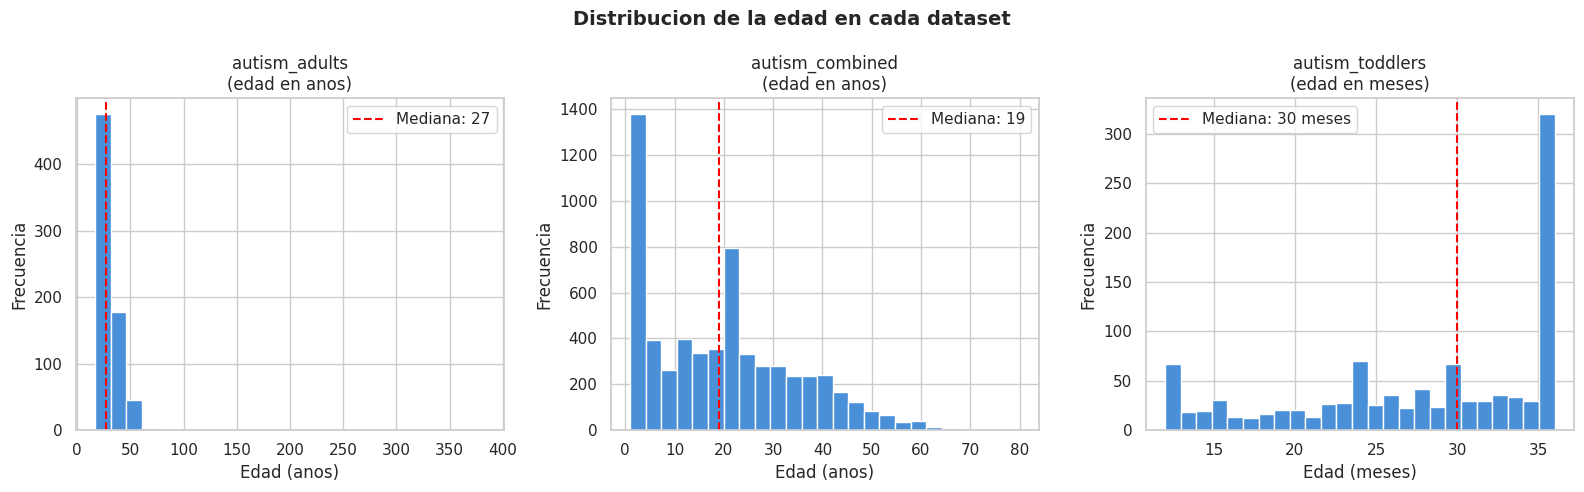

Estadisticos de edad:
  autism_adults:   min=17.0, max=383.0, mediana=27, media=29.7
  autism_combined: min=1, max=80, mediana=19, media=19.8
  autism_toddlers: min=12, max=36, mediana=30 meses, media=27.9 meses


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# autism_adults: edad en anos
autism_adults["age"].hist(bins=25, ax=axes[0], color="#4a90d9", edgecolor="white")
axes[0].set_title("autism_adults\n(edad en anos)")
axes[0].set_xlabel("Edad (anos)")
axes[0].set_ylabel("Frecuencia")
axes[0].axvline(autism_adults["age"].median(), color="red", linestyle="--", label=f"Mediana: {autism_adults['age'].median():.0f}")
axes[0].legend()

# autism_combined: edad en anos
autism_combined["Age"].hist(bins=25, ax=axes[1], color="#4a90d9", edgecolor="white")
axes[1].set_title("autism_combined\n(edad en anos)")
axes[1].set_xlabel("Edad (anos)")
axes[1].set_ylabel("Frecuencia")
axes[1].axvline(autism_combined["Age"].median(), color="red", linestyle="--", label=f"Mediana: {autism_combined['Age'].median():.0f}")
axes[1].legend()

# autism_toddlers: edad en MESES
autism_toddlers["Age_Mons"].hist(bins=25, ax=axes[2], color="#4a90d9", edgecolor="white")
axes[2].set_title("autism_toddlers\n(edad en meses)")
axes[2].set_xlabel("Edad (meses)")
axes[2].set_ylabel("Frecuencia")
axes[2].axvline(autism_toddlers["Age_Mons"].median(), color="red", linestyle="--", label=f"Mediana: {autism_toddlers['Age_Mons'].median():.0f} meses")
axes[2].legend()

plt.suptitle("Distribucion de la edad en cada dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../docs/assets/img/distribucion_edad.png", dpi=150, bbox_inches="tight")
plt.show()

# Estadisticos descriptivos
print("Estadisticos de edad:")
print(f"  autism_adults:   min={autism_adults['age'].min()}, max={autism_adults['age'].max()}, mediana={autism_adults['age'].median():.0f}, media={autism_adults['age'].mean():.1f}")
print(f"  autism_combined: min={autism_combined['Age'].min()}, max={autism_combined['Age'].max()}, mediana={autism_combined['Age'].median():.0f}, media={autism_combined['Age'].mean():.1f}")
print(f"  autism_toddlers: min={autism_toddlers['Age_Mons'].min()}, max={autism_toddlers['Age_Mons'].max()}, mediana={autism_toddlers['Age_Mons'].median():.0f} meses, media={autism_toddlers['Age_Mons'].mean():.1f} meses")


## 6. Distribucion por sexo

El TEA tiene una prevalencia diferente segun el sexo: se diagnostica con mas
frecuencia en hombres que en mujeres, aunque hay evidencia de que en mujeres
puede estar infradiagnosticado porque la presentacion clinica es diferente.
Veamos como se distribuye el sexo en nuestros datasets.


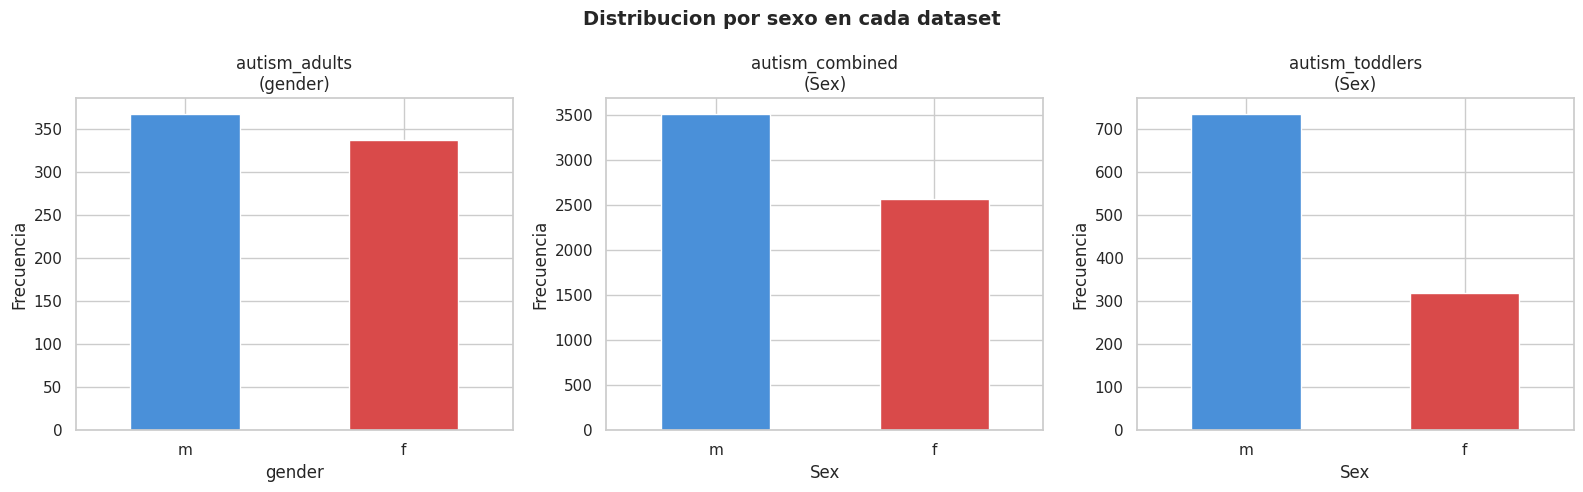

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# autism_adults
autism_adults["gender"].value_counts().plot(kind="bar", ax=axes[0], color=["#4a90d9", "#d94a4a"])
axes[0].set_title("autism_adults\n(gender)")
axes[0].set_ylabel("Frecuencia")
axes[0].tick_params(axis="x", rotation=0)

# autism_combined
autism_combined["Sex"].value_counts().plot(kind="bar", ax=axes[1], color=["#4a90d9", "#d94a4a"])
axes[1].set_title("autism_combined\n(Sex)")
axes[1].set_ylabel("Frecuencia")
axes[1].tick_params(axis="x", rotation=0)

# autism_toddlers
autism_toddlers["Sex"].value_counts().plot(kind="bar", ax=axes[2], color=["#4a90d9", "#d94a4a"])
axes[2].set_title("autism_toddlers\n(Sex)")
axes[2].set_ylabel("Frecuencia")
axes[2].tick_params(axis="x", rotation=0)

plt.suptitle("Distribucion por sexo en cada dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../docs/assets/img/distribucion_sexo.png", dpi=150, bbox_inches="tight")
plt.show()


### 6.1 Relacion entre sexo y resultado del cribado

Veamos si el resultado del cribado varia significativamente entre sexos.
Esto es relevante tanto para entender posibles sesgos del dataset como
para interpretar los resultados del modelo.


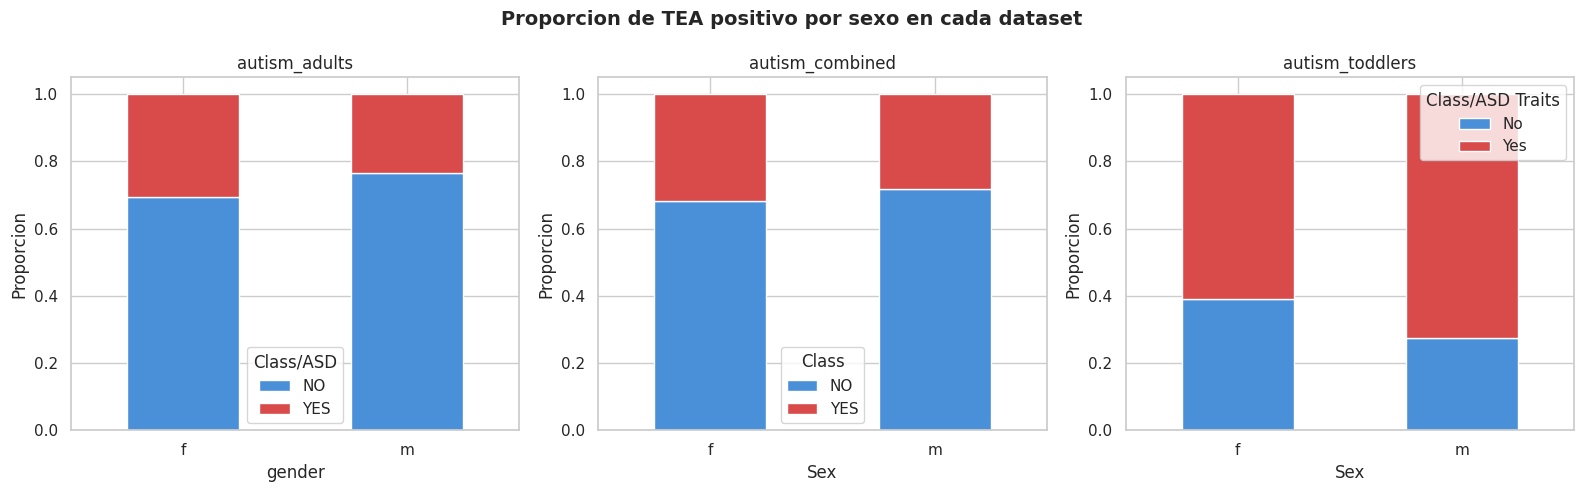

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# autism_adults
pd.crosstab(autism_adults["gender"], autism_adults["Class/ASD"], normalize="index").plot(
    kind="bar", stacked=True, ax=axes[0], color=["#4a90d9", "#d94a4a"]
)
axes[0].set_title("autism_adults")
axes[0].set_ylabel("Proporcion")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Class/ASD")

# autism_combined
pd.crosstab(autism_combined["Sex"], autism_combined["Class"], normalize="index").plot(
    kind="bar", stacked=True, ax=axes[1], color=["#4a90d9", "#d94a4a"]
)
axes[1].set_title("autism_combined")
axes[1].set_ylabel("Proporcion")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Class")

# autism_toddlers
pd.crosstab(autism_toddlers["Sex"], autism_toddlers["Class/ASD Traits "], normalize="index").plot(
    kind="bar", stacked=True, ax=axes[2], color=["#4a90d9", "#d94a4a"]
)
axes[2].set_title("autism_toddlers")
axes[2].set_ylabel("Proporcion")
axes[2].tick_params(axis="x", rotation=0)
axes[2].legend(title="Class/ASD Traits")

plt.suptitle("Proporcion de TEA positivo por sexo en cada dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../docs/assets/img/sexo_vs_target.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Antecedentes familiares de TEA

Los antecedentes familiares son un factor de riesgo conocido para el TEA.
Veamos como se distribuye esta variable y si tiene relacion con el resultado
del cribado en nuestros datasets.


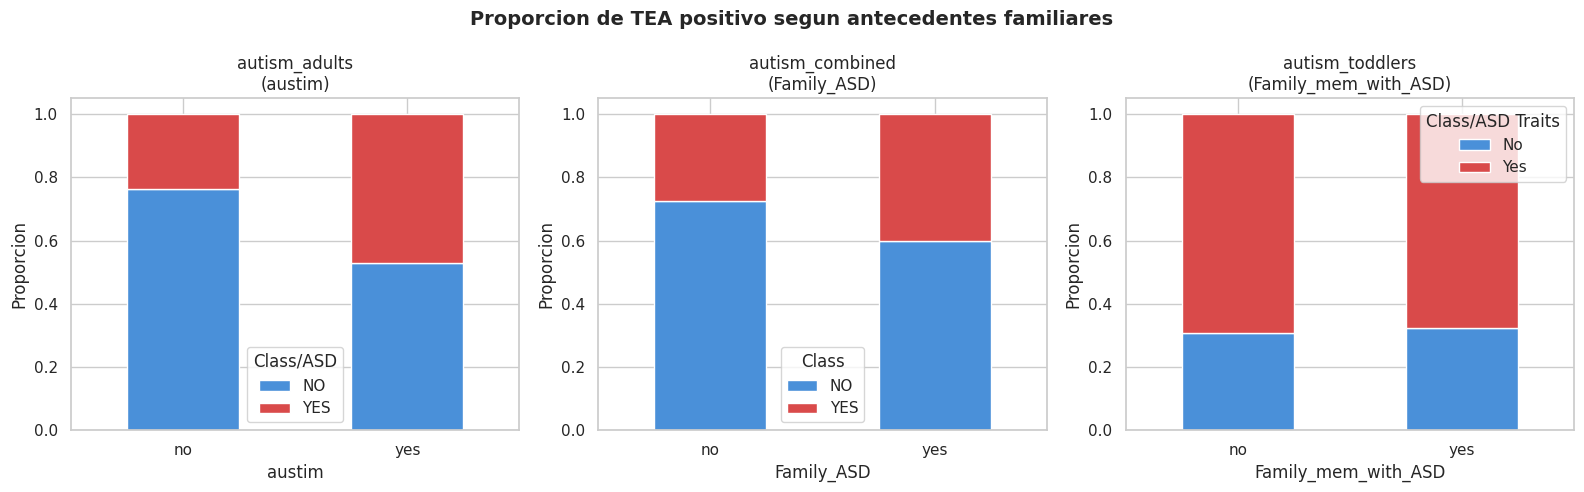

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# autism_adults: columna 'austim' (si, esta mal escrita en el dataset original)
pd.crosstab(autism_adults["austim"], autism_adults["Class/ASD"], normalize="index").plot(
    kind="bar", stacked=True, ax=axes[0], color=["#4a90d9", "#d94a4a"]
)
axes[0].set_title("autism_adults\n(austim)")
axes[0].set_ylabel("Proporcion")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Class/ASD")

# autism_combined
pd.crosstab(autism_combined["Family_ASD"], autism_combined["Class"], normalize="index").plot(
    kind="bar", stacked=True, ax=axes[1], color=["#4a90d9", "#d94a4a"]
)
axes[1].set_title("autism_combined\n(Family_ASD)")
axes[1].set_ylabel("Proporcion")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Class")

# autism_toddlers
pd.crosstab(autism_toddlers["Family_mem_with_ASD"], autism_toddlers["Class/ASD Traits "], normalize="index").plot(
    kind="bar", stacked=True, ax=axes[2], color=["#4a90d9", "#d94a4a"]
)
axes[2].set_title("autism_toddlers\n(Family_mem_with_ASD)")
axes[2].set_ylabel("Proporcion")
axes[2].tick_params(axis="x", rotation=0)
axes[2].legend(title="Class/ASD Traits")

plt.suptitle("Proporcion de TEA positivo segun antecedentes familiares", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../docs/assets/img/antecedentes_familiares.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Ictericia neonatal (jaundice)

La ictericia neonatal se ha estudiado como posible factor de riesgo asociado
al TEA. Veamos como se distribuye en nuestros datasets y si hay diferencia
en el resultado del cribado.


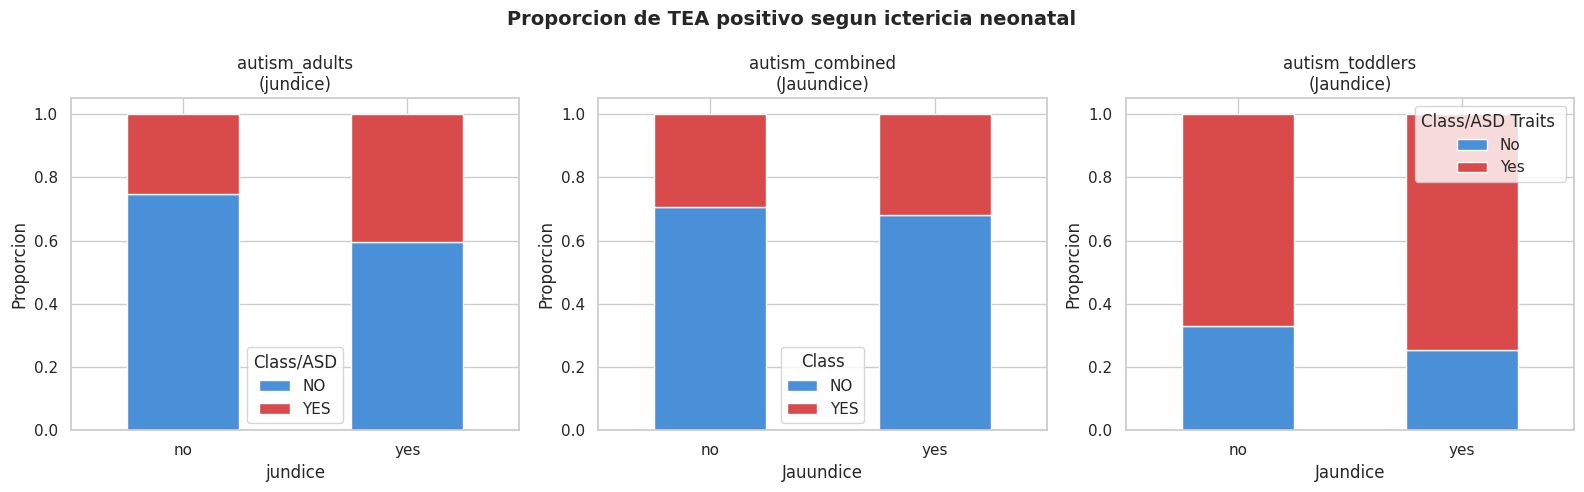

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# autism_adults
pd.crosstab(autism_adults["jundice"], autism_adults["Class/ASD"], normalize="index").plot(
    kind="bar", stacked=True, ax=axes[0], color=["#4a90d9", "#d94a4a"]
)
axes[0].set_title("autism_adults\n(jundice)")
axes[0].set_ylabel("Proporcion")
axes[0].tick_params(axis="x", rotation=0)

# autism_combined
pd.crosstab(autism_combined["Jauundice"], autism_combined["Class"], normalize="index").plot(
    kind="bar", stacked=True, ax=axes[1], color=["#4a90d9", "#d94a4a"]
)
axes[1].set_title("autism_combined\n(Jauundice)")
axes[1].set_ylabel("Proporcion")
axes[1].tick_params(axis="x", rotation=0)

# autism_toddlers
pd.crosstab(autism_toddlers["Jaundice"], autism_toddlers["Class/ASD Traits "], normalize="index").plot(
    kind="bar", stacked=True, ax=axes[2], color=["#4a90d9", "#d94a4a"]
)
axes[2].set_title("autism_toddlers\n(Jaundice)")
axes[2].set_ylabel("Proporcion")
axes[2].tick_params(axis="x", rotation=0)

plt.suptitle("Proporcion de TEA positivo segun ictericia neonatal", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../docs/assets/img/ictericia_vs_target.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Distribucion de las respuestas del cuestionario AQ-10

Las columnas A1 a A10 contienen las respuestas a las 10 preguntas del
cuestionario AQ-10. Cada respuesta es binaria (0 o 1). Vamos a ver
como se distribuyen las respuestas y si alguna pregunta tiene mas
poder predictivo que las demas.


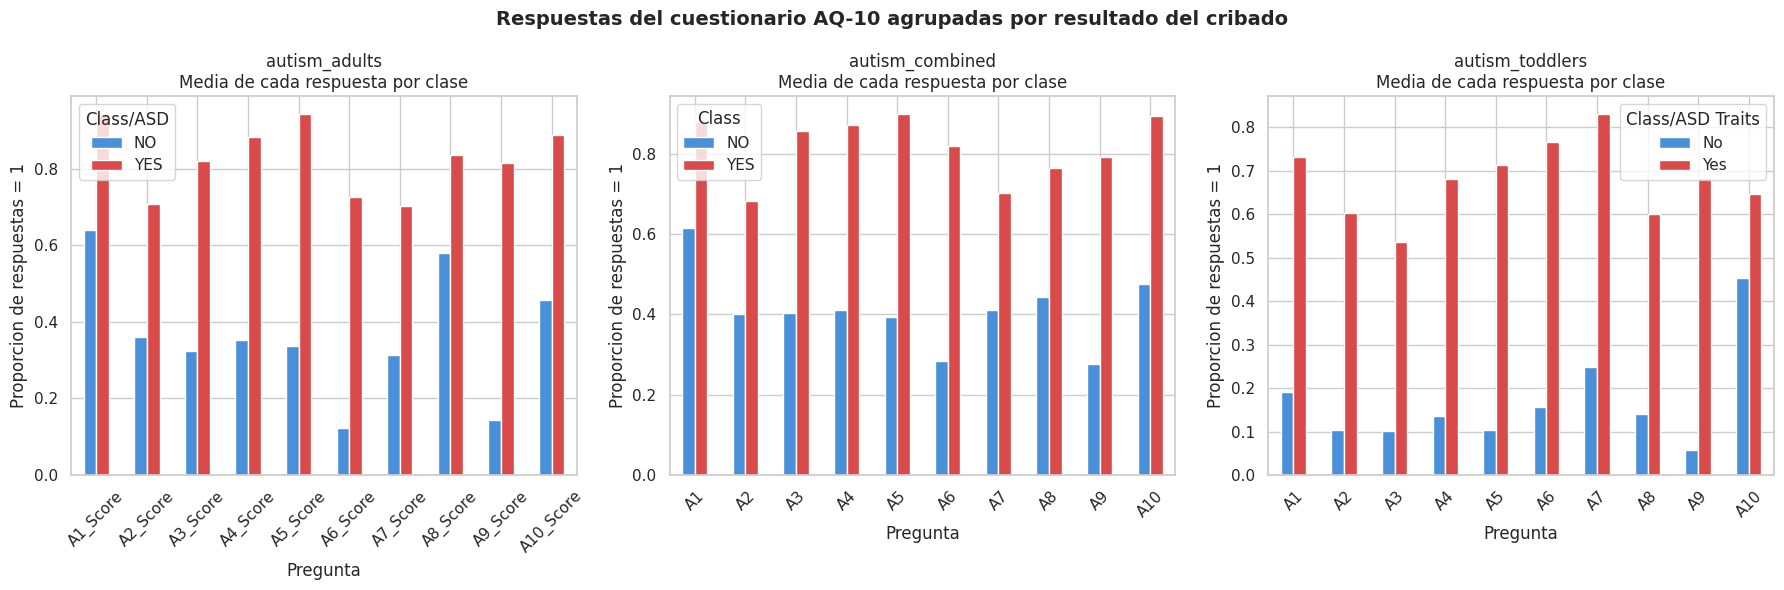

In [ ]:
# Calculamos la media de cada respuesta (proporcion de "1") agrupada por resultado del cribado
# Esto nos dice que preguntas tienen mas diferencia entre los que dan positivo y negativo

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# autism_adults
score_cols_adults = [f"A{i}_Score" for i in range(1, 11)]
medias_adults = autism_adults.groupby("Class/ASD")[score_cols_adults].mean()
medias_adults.T.plot(kind="bar", ax=axes[0], color=["#4a90d9", "#d94a4a"])
axes[0].set_title("autism_adults\nMedia de cada respuesta por clase")
axes[0].set_ylabel("Proporcion de respuestas = 1")
axes[0].set_xlabel("Pregunta")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="Class/ASD")

# autism_combined
score_cols_combined = [f"A{i}" for i in range(1, 11)]
medias_combined = autism_combined.groupby("Class")[score_cols_combined].mean()
medias_combined.T.plot(kind="bar", ax=axes[1], color=["#4a90d9", "#d94a4a"])
axes[1].set_title("autism_combined\nMedia de cada respuesta por clase")
axes[1].set_ylabel("Proporcion de respuestas = 1")
axes[1].set_xlabel("Pregunta")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="Class")

# autism_toddlers
score_cols_toddlers = [f"A{i}" for i in range(1, 11)]
medias_toddlers = autism_toddlers.groupby("Class/ASD Traits ")[score_cols_toddlers].mean()
medias_toddlers.T.plot(kind="bar", ax=axes[2], color=["#4a90d9", "#d94a4a"])
axes[2].set_title("autism_toddlers\nMedia de cada respuesta por clase")
axes[2].set_ylabel("Proporcion de respuestas = 1")
axes[2].set_xlabel("Pregunta")
axes[2].tick_params(axis="x", rotation=45)
axes[2].legend(title="Class/ASD Traits")

plt.suptitle("Respuestas del cuestionario AQ-10 agrupadas por resultado del cribado", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../docs/assets/img/respuestas_aq10.png", dpi=150, bbox_inches="tight")
plt.show()


### Observaciones sobre las respuestas AQ-10

Este grafico es clave para el proyecto. Muestra que hay preguntas donde la
diferencia entre los que dan positivo y negativo en el cribado es muy grande.
Esas preguntas seran probablemente las features mas importantes para el modelo.

Las preguntas donde la barra roja (YES/positivo) y la azul (NO/negativo)
estan mas separadas son las que tienen mayor poder discriminativo.


## 10. Matriz de correlacion

Calculamos la correlacion entre las variables numericas de cada dataset.
Esto nos ayuda a detectar si hay variables redundantes (muy correlacionadas
entre si) que podriamos eliminar o combinar.


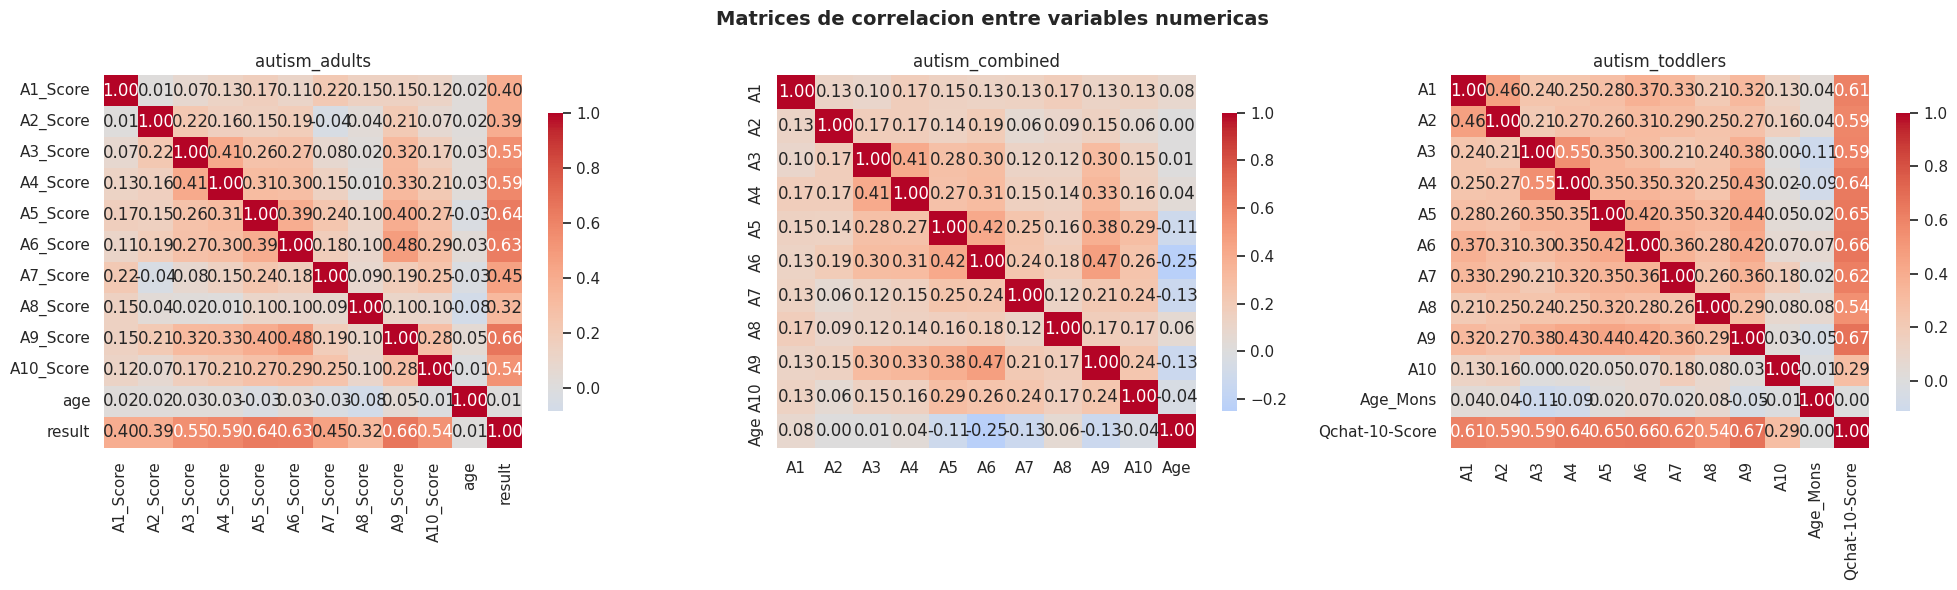

In [ ]:
# Matriz de correlacion para autism_adults
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# autism_adults
corr_adults = autism_adults[score_cols_adults + ["age", "result"]].corr()
sns.heatmap(corr_adults, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            ax=axes[0], cbar_kws={"shrink": 0.8})
axes[0].set_title("autism_adults")

# autism_combined
corr_combined = autism_combined[score_cols_combined + ["Age"]].corr()
sns.heatmap(corr_combined, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            ax=axes[1], cbar_kws={"shrink": 0.8})
axes[1].set_title("autism_combined")

# autism_toddlers
corr_toddlers = autism_toddlers[score_cols_toddlers + ["Age_Mons", "Qchat-10-Score"]].corr()
sns.heatmap(corr_toddlers, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            ax=axes[2], cbar_kws={"shrink": 0.8})
axes[2].set_title("autism_toddlers")

plt.suptitle("Matrices de correlacion entre variables numericas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../docs/assets/img/correlacion.png", dpi=150, bbox_inches="tight")
plt.show()


### Observaciones sobre la correlacion

- Las respuestas del cuestionario (A1 a A10) tienen correlaciones bajas-moderadas
  entre si en general, lo cual es bueno: significa que cada pregunta aporta
  informacion diferente y no son redundantes.
- La edad no esta fuertemente correlacionada con ninguna respuesta del cuestionario
  en ningun dataset.
- En autism_adults, la columna 'result' (puntuacion total del AQ-10) esta
  logicamente correlacionada con las respuestas individuales, ya que es su suma.
  No la usaremos como feature para evitar data leakage (es practicamente el target).
- En autism_toddlers, 'Qchat-10-Score' es equivalente a 'result': la suma de A1 a A10.
  Tampoco la usaremos como feature.


## 11. Puntuacion total del cuestionario vs resultado del cribado

Visualizamos la distribucion de la puntuacion total del cuestionario
(suma de A1 a A10) separada por resultado del cribado. Esto nos da una
idea de si el cuestionario por si solo ya separa bien las dos clases.


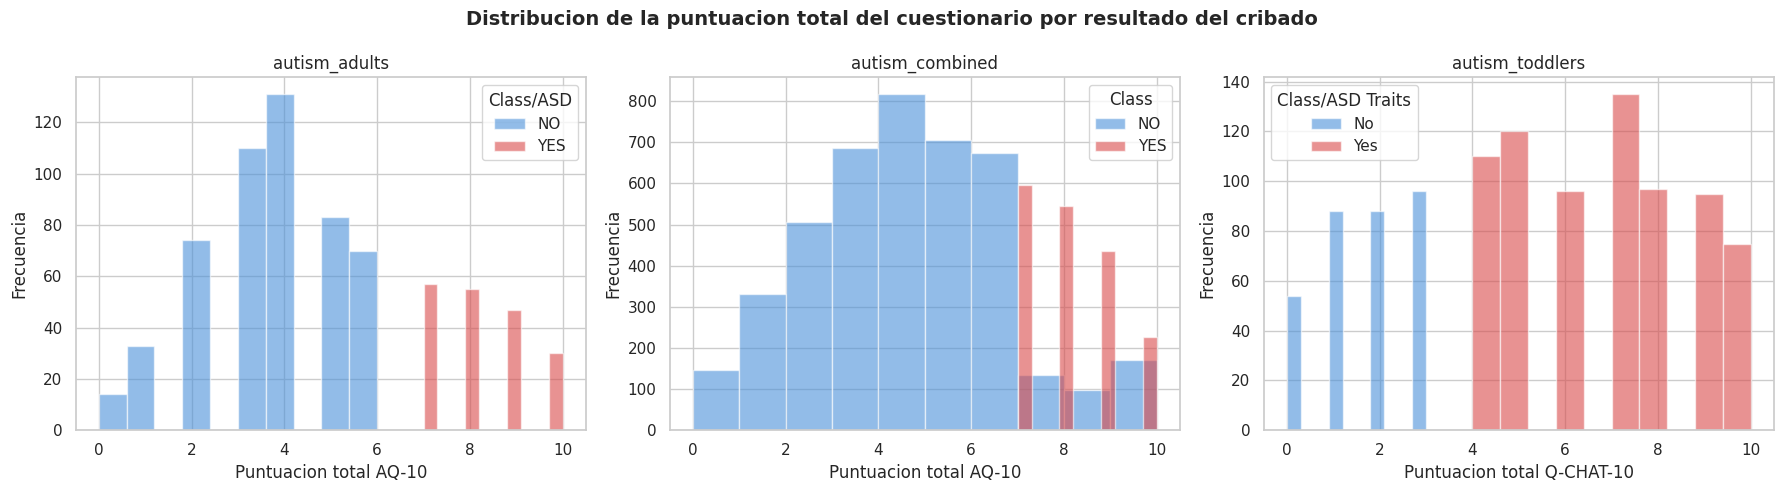

In [ ]:
# Calculamos la puntuacion total si no existe ya como columna
autism_adults["score_total"] = autism_adults[score_cols_adults].sum(axis=1)
autism_combined["score_total"] = autism_combined[score_cols_combined].sum(axis=1)
autism_toddlers["score_total"] = autism_toddlers[score_cols_toddlers].sum(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# autism_adults
for clase in ["NO", "YES"]:
    subset = autism_adults[autism_adults["Class/ASD"] == clase]
    axes[0].hist(subset["score_total"], bins=10, alpha=0.6, label=clase,
                 color="#4a90d9" if clase == "NO" else "#d94a4a", edgecolor="white")
axes[0].set_title("autism_adults")
axes[0].set_xlabel("Puntuacion total AQ-10")
axes[0].set_ylabel("Frecuencia")
axes[0].legend(title="Class/ASD")

# autism_combined
for clase in ["NO", "YES"]:
    subset = autism_combined[autism_combined["Class"] == clase]
    axes[1].hist(subset["score_total"], bins=10, alpha=0.6, label=clase,
                 color="#4a90d9" if clase == "NO" else "#d94a4a", edgecolor="white")
axes[1].set_title("autism_combined")
axes[1].set_xlabel("Puntuacion total AQ-10")
axes[1].set_ylabel("Frecuencia")
axes[1].legend(title="Class")

# autism_toddlers
for clase in ["No", "Yes"]:
    subset = autism_toddlers[autism_toddlers["Class/ASD Traits "] == clase]
    axes[2].hist(subset["score_total"], bins=10, alpha=0.6, label=clase,
                 color="#4a90d9" if clase == "No" else "#d94a4a", edgecolor="white")
axes[2].set_title("autism_toddlers")
axes[2].set_xlabel("Puntuacion total Q-CHAT-10")
axes[2].set_ylabel("Frecuencia")
axes[2].legend(title="Class/ASD Traits")

plt.suptitle("Distribucion de la puntuacion total del cuestionario por resultado del cribado", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../docs/assets/img/score_total_vs_target.png", dpi=150, bbox_inches="tight")
plt.show()


### Observaciones sobre la puntuacion total

Las distribuciones de puntuacion total estan bastante separadas entre las
dos clases en los tres datasets. Esto es una buena senal: indica que las
respuestas del cuestionario si contienen informacion predictiva real sobre
el resultado del cribado. Nuestro modelo deberia ser capaz de aprovechar
esta senal para hacer predicciones utiles.


## 12. Resumen del EDA y decisiones para el preprocesamiento

### Hallazgos principales

1. **Tamano de los datasets**: autism_adults (704), autism_combined (6075),
   autism_toddlers (1054). En total tenemos 7833 registros.

2. **Valores faltantes**: solo 2 en la columna 'age' de autism_adults.
   Decision: los imputaremos con la mediana. Tambien hay valores '?' en
   columnas categoricas de autism_adults que trataremos como categoria
   "desconocido" o imputaremos con la moda.

3. **Desbalance de clases**: existe en los tres datasets, pero no es extremo.
   Decision: usaremos pesos de clase ajustados (class_weight='balanced') en
   los modelos y priorizaremos recall como metrica principal.

4. **Senal predictiva**: las respuestas del cuestionario AQ-10 tienen una
   relacion clara con el resultado del cribado. La puntuacion total ya
   separa razonablemente bien las dos clases. Esto confirma que hay senal
   suficiente para entrenar un modelo util.

5. **Columnas a excluir del feature set**:
   - 'result' (autism_adults) y 'Qchat-10-Score' (autism_toddlers): son la
     suma de A1-A10, usarlas seria casi como usar el target como feature.
   - 'score_total': la hemos calculado nosotros, mismo problema.
   - 'age_desc' (autism_adults): es redundante con 'age'.
   - 'Case_No' (autism_toddlers): es un identificador, no aporta informacion.

6. **Variables categoricas a codificar**: gender/Sex, ethnicity/Ethnicity,
   jundice/Jauundice/Jaundice, austim/Family_ASD/Family_mem_with_ASD,
   relation/Who completed the test, contry_of_res.

7. **Sesgo potencial**: el dataset esta dominado por poblacion anglosajona
   y los criterios de cribado son DSM-5. La presentacion clinica del TEA
   en mujeres puede diferir, lo que podria afectar al rendimiento del
   modelo en poblaciones subrepresentadas. Esto es una limitacion que
   documentaremos explicitamente.

### Decisiones para el preprocesamiento (notebook 02)

- Imputar los 2 valores faltantes de 'age' con la mediana.
- Tratar los '?' como categoria 'unknown' o imputar con la moda.
- Aplicar One-Hot Encoding a las variables categoricas.
- Escalar las variables numericas (edad) con StandardScaler.
- Dividir en 80% train / 20% test ANTES de ajustar cualquier transformacion.
- Usar Pipeline de scikit-learn para evitar data leakage.
- Considerar SMOTE solo si los modelos tienen problemas claros con los falsos negativos.
